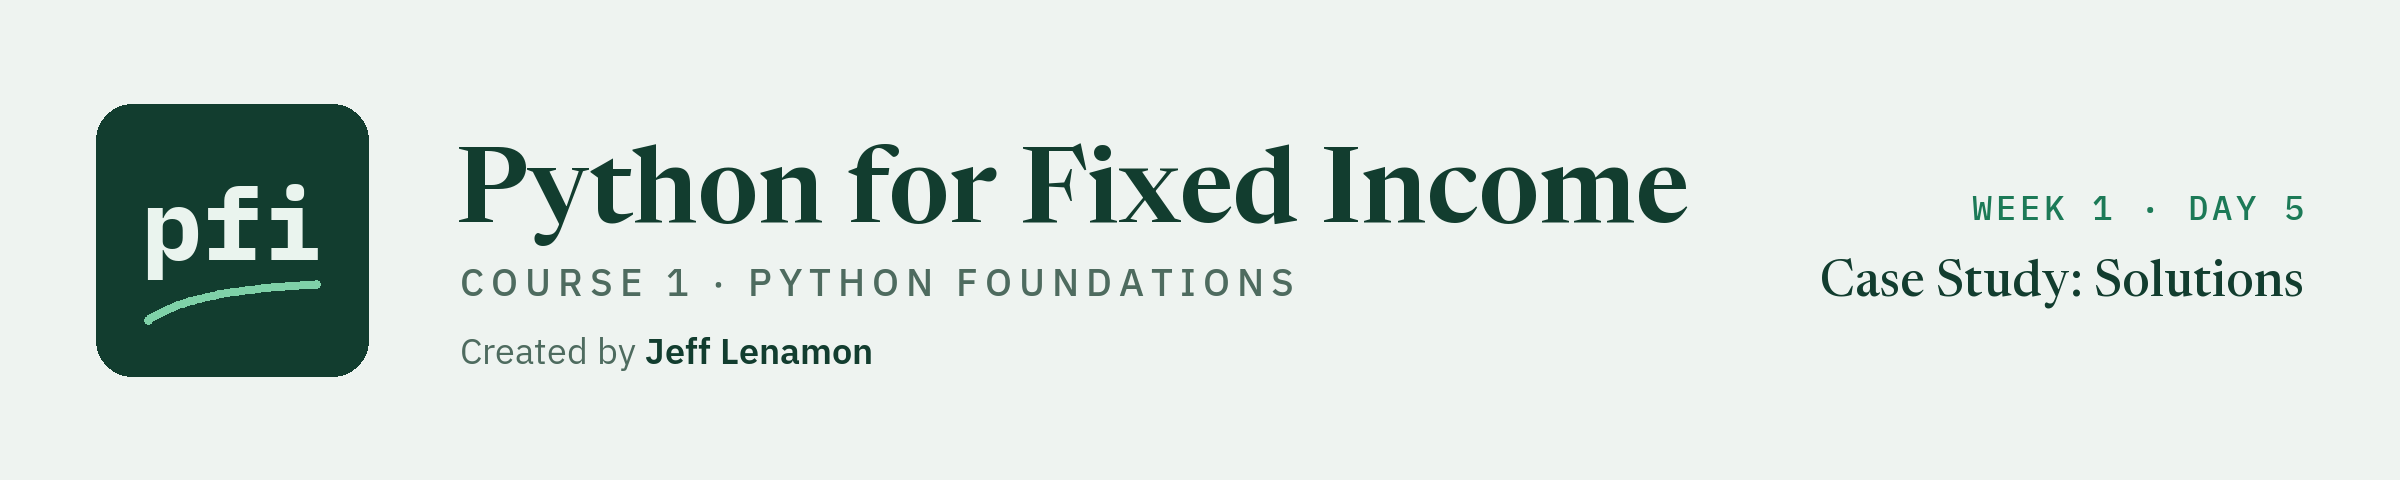

# Case Study: Organizing a Small Portfolio - Solutions

Week 1. Worked answers to the exercises. Try each one yourself first.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course1_python_foundations/week1/day5/05_case_study_a_small_portfolio_solutions.ipynb)

## Exercises

A second, smaller portfolio has arrived the same way. The issuers are invented.

| Ticker | Rating | Score | Coupon (%) | Price | Face held |
| --- | --- | --- | --- | --- | --- |
| TRNW | A | 6 | 4.375 | 96.25 | 2,000,000 |
| OSMC | BBB- | 10 | 5.00 | 100.00 | 1,250,000 |
| CLDB | B | 15 | 8.25 | 104.50 | 500,000 |

Replace each `...` with your own code, then run the check cell under it. Worked answers are in the solutions notebook in this folder.

Run the next cell first. It defines `check` and loads the portfolio as lists.

In [1]:
def check(label, answer, expected):
    """Compare an exercise answer to the expected value and print the result."""
    if answer is ... or answer is None:
        print(label + ': not attempted yet')
    elif answer == expected:
        print(label + ': correct')
    else:
        print(label + ': not yet. You have', answer)


# the second portfolio
ticker_list = ['TRNW', 'OSMC', 'CLDB']
score_list = [6, 10, 15]
coupon_list = [4.375, 5.0, 8.25]
price_list = [96.25, 100.0, 104.5]
face_list = [2000000, 1250000, 500000]

### Exercise 1

Q. Use `index()` to find the position of OSMC, then use that position to get its price. Store the price in **ex1_price**.

In [2]:
# find the position of OSMC
pos = ticker_list.index('OSMC')
# read the price at that position
ex1_price = price_list[pos]
print('The price of OSMC is', ex1_price)

The price of OSMC is 100.0


In [3]:
check('Exercise 1', ex1_price, 100.0)

Exercise 1: correct


### Exercise 2

Q. Use a loop and a condition to count the investment grade bonds, those with a score of 10 or lower. Store the count in **ex2_ig_count**.

In [4]:
# start a counter at zero
ex2_ig_count = 0
# counting only reads the scores, so loop over the list itself
for score in score_list:
    # <= includes a score of exactly 10
    if score <= 10:
        ex2_ig_count = ex2_ig_count + 1

print('Investment grade bonds:', ex2_ig_count)

Investment grade bonds: 2


* TRNW and OSMC. OSMC sits exactly on the line with a score of 10, so the test must be `<=` and not `<`.

In [5]:
check('Exercise 2', ex2_ig_count, 2)

Exercise 2: correct


### Exercise 3

Q. Complete the function **bond_cost** so that it takes a ticker and returns the cost of that position at the clean price: face times price divided by 100, with accrued interest left out. Then the code stores the cost of CLDB in **ex3_cost**.

In [6]:
def bond_cost(ticker):
    """
    Take a ticker and return
    the cost of that position.
    """
    # find the position of the ticker
    pos = ticker_list.index(ticker)
    # the price is per 100 face, so divide by 100
    return face_list[pos] * price_list[pos] / 100


ex3_cost = bond_cost('CLDB')
print('The cost of CLDB is', ex3_cost)

The cost of CLDB is 522500.0


In [7]:
check('Exercise 3', ex3_cost, 522500.0)

Exercise 3: correct


### Exercise 4

Q. Combine the five lists into a dictionary with the keys 'Ticker', 'Score', 'Coupon', 'Price', and 'Face'. Turn it into a DataFrame. Store its shape in **ex4_shape**.

In [8]:
import pandas as pd

# each key is a column name, and each value is the list for that column
second_portfolio = {
    'Ticker': ticker_list,
    'Score': score_list,
    'Coupon': coupon_list,
    'Price': price_list,
    'Face': face_list
}
# build the table
second_df = pd.DataFrame(second_portfolio)
ex4_shape = second_df.shape
print(ex4_shape)

(3, 5)


In [9]:
second_df

,Ticker,Score,Coupon,Price,Face
0,TRNW,6,4.375,96.25,2000000
1,OSMC,10,5.000,100.00,1250000
2,CLDB,15,8.250,104.50,500000


* Three rows for three bonds, and five columns for the five keys.

In [10]:
check('Exercise 4', ex4_shape, (3, 5))

Exercise 4: correct


### Exercise 5

Q. Complete the function **total_face**. It takes a table with a 'Face' column and returns the total face held. The cell builds the table **second_df** for you. The check calls your function twice: on the whole table, and on its first two rows.

In [11]:
import pandas as pd

# the second portfolio as a table
second_df = pd.DataFrame({
    'Ticker': ticker_list,
    'Score': score_list,
    'Coupon': coupon_list,
    'Price': price_list,
    'Face': face_list
})


def total_face(table):
    """
    Take a table with a 'Face' column
    and return the total face held.
    """
    # pick the column by its name and add it up
    return table['Face'].sum()


# the function must agree with the list the table was built from
assert total_face(second_df) == sum(face_list), 'the table and the list do not agree'

print(f'Whole table: {total_face(second_df):,}')
# head(2) is a table too, so the same function works on it
print(f'First two rows: {total_face(second_df.head(2)):,}')

Whole table: 3,750,000
First two rows: 3,250,000


* 3,750,000 for the three bonds, and 3,250,000 for TRNW and OSMC alone. The function uses the table it is handed, not a fixed one, so it works on any table with a 'Face' column.
* It returns the number and prints nothing. The printing and the `assert` are done by the code that calls it.

In [12]:
check('Exercise 5 whole table', total_face(second_df), 3750000)
check('Exercise 5 first two rows', total_face(second_df.head(2)), 3250000)

Exercise 5 whole table: correct
Exercise 5 first two rows: correct


### Exercise 6: AI check

You ask an AI assistant for code that totals the cost of the three positions at the clean price. It gives you the code below. It was written for this course in the style of an AI answer, and it has one bug.

Q. Before you run it, work out the total yourself. The three costs are 1,925,000, 1,250,000, and 522,500. Then run the code. Does it agree with you?

* The three costs add up to 3,697,500. The original code printed 3,175,000, with no error.
* The bug was `range(len(ticker_list) - 1)`. The list has three items, so that is `range(2)`, which produces 0 and 1 and never reaches the last bond. The missing 522,500 is exactly the cost of CLDB.
* `range(len(ticker_list))` already stops at the right place. Subtracting 1 is a common mistake that silently drops the last row. Looping over the lists themselves, with `zip(face_list, price_list)`, needs no index and avoids this bug altogether.

In [13]:
ex6_total_cost = 0
# range(len(ticker_list)) covers every position, including the last
for i in range(len(ticker_list)):
    ex6_total_cost = ex6_total_cost + face_list[i] * price_list[i] / 100

print(f'The total cost is {ex6_total_cost:,.2f}')

The total cost is 3,697,500.00


In [14]:
check('Exercise 6', ex6_total_cost, 3697500.0)

Exercise 6: correct
